# Building an AI-Powered Tweet Emotion Classifier with OpenAI

Learn how to build a production-ready emotion classification system for tweets using OpenAI's GPT-5-nano model. This end-to-end guide covers data loading, API integration, evaluation, and cost analysis.

## What You'll Learn
- **Dataset**: SMILE Twitter Emotion dataset (3,085 tweets)
- **Emotions**: Anger, Disgust, Happiness, Surprise, Sadness
- **Technology**: OpenAI GPT-5-nano API
- **Approach**: Multi-score emotion intensity classification
- **Skills**: API integration, evaluation metrics, cost estimation
- **Bonus**: Practical insights on scaling GenAI applications

## Step 1: Setup & Dependencies

Import the required libraries for data handling, API integration, and model evaluation:

In [1]:
import os
import pandas as pd
from google import genai
from sklearn.metrics import accuracy_score
import random
import re
from openai import OpenAI
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the SMILE Dataset

Load the SMILE Twitter Emotion dataset and explore its structure:

In [21]:
# Load the dataset
df = pd.read_csv('data/smile-annotations-final.csv', header=None, names=['tweet_id', 'tweet_text', 'emotion'])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3085, 3)


,tweet_id,tweet_text,emotion
0,611857364396965889,@aandraous @britishmuseum @AndrewsAntonio Merc...,nocode
1,614484565059596288,Dorian Gray with Rainbow Scarf #LoveWins (from...,happy
2,614746522043973632,@SelectShowcase @Tate_StIves ... Replace with ...,happy
3,614877582664835073,@Sofabsports thank you for following me back. ...,happy
4,611932373039644672,@britishmuseum @TudorHistory What a beautiful ...,happy


### Explore Emotion Distribution

Check the balance of emotion labels in the dataset:

In [3]:
df["emotion"].value_counts()

emotion
nocode               1572
happy                1137
not-relevant          214
angry                  57
surprise               35
sad                    32
happy|surprise         11
happy|sad               9
disgust|angry           7
disgust                 6
sad|disgust             2
sad|angry               2
sad|disgust|angry       1
Name: count, dtype: int64

## Step 3: Initialize the OpenAI API Client

Set up the OpenAI client and define a helper function for API calls:

In [ ]:
# Initialize the client
openai_api_key = os.getenv('OPENAI_API_KEY')

openai_client = OpenAI(api_key=openai_api_key)

# defining the OpenAI function
def call_openai(messages_list, response_format="text"):
    response = openai_client.chat.completions.create(
        model="gpt-5-nano",
        messages=messages_list,
        temperature=1,
        reasoning_effort="low",
        response_format={"type": response_format}
    )
    return response
        
# testing the function
messages_list = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Who won the World Series in 2020? Please answer in 20 words."}
]
response = call_openai(messages_list)

print(response)


ChatCompletion(id='chatcmpl-CzMskQYkNb0qqoDZTaErqVApaZNey', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='The Los Angeles Dodgers won the 2020 World Series, defeating the Tampa Bay Rays in six games to claim title.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1768742002, model='gpt-5-nano-2025-08-07', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=418, prompt_tokens=33, total_tokens=451, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=384, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))


### Test the API Connection

Verify that the API is working correctly:

In [5]:
print(response.choices[0].message.content)

The Los Angeles Dodgers won the 2020 World Series, defeating the Tampa Bay Rays in six games to claim title.


## Step 4: Design the Emotion Classification Prompt

Create a structured prompt that returns emotion intensity scores as JSON:

In [6]:
## Defining the Prompt
prompt = f"""Analyze the emotional content of the following tweet.

    For EACH of the following emotions, assign an intensity score between 0 and 1:
    - anger
    - disgust
    - happy
    - surprise
    - sad

    Where:
    0 = emotion not present
    1 = extremely strong presence of the emotion

    Return ONLY valid JSON in the exact format below:
    {{
    "anger": <number between 0 and 1>,
    "disgust": <number between 0 and 1>,
    "happy": <number between 0 and 1>,
    "surprise": <number between 0 and 1>,
    "sad": <number between 0 and 1>
    }}

    Do not include explanations, markdown, or extra text.

    Tweet: {{tweet_text}}"""

## Step 5: Build the Classification Function

Implement the core `classify_emotion()` function that calls the API and processes results:

In [7]:
import json

def classify_emotion(tweet_text, prompt):
    """
    Classify the emotional intensities of a tweet using Gemini API.
    Returns:
        emotions (dict): emotion -> intensity (0 to 1)
        input_tokens (int)
        output_tokens (int)
        raw_text (str): raw model output
    """
    prompt = prompt.replace("{tweet_text}", tweet_text)

    messages_list = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    
    response = call_openai(messages_list, response_format="json_object")
    #print(response)
    raw_text = response.choices[0].message.content

    # Token usage
    input_tokens = response.usage.prompt_tokens
    reasoning_tokens = response.usage.completion_tokens_details.reasoning_tokens
    output_tokens = response.usage.completion_tokens

    # Default fallback
    emotions = {
        "anger": 0.0,
        "disgust": 0.0,
        "happy": 0.0,
        "surprise": 0.0,
        "sad": 0.0,
    }


    try:
        # 🔑 Extract JSON object even if wrapped in text or markdown
        json_match = re.search(r"\{.*\}", raw_text, re.DOTALL)
        if not json_match:
            raise ValueError("No JSON object found in model output")

        parsed = json.loads(json_match.group())

        for key in emotions:
            if key in parsed:
                value = float(parsed[key])
                emotions[key] = max(0.0, min(1.0, value))

    except Exception as e:
        print("JSON parsing failed:", e)

    return emotions, input_tokens, reasoning_tokens, output_tokens, 


# Test the function
test_tweet = "I love this beautiful painting!"
emotions, in_tok, reasoning_tokens, out_tok = classify_emotion(test_tweet, prompt)
print(f"Test: {emotions}, Input tokens: {in_tok}, Reasoning tokens: {reasoning_tokens}, Output tokens: {out_tok}")

Test: {'anger': 0.0, 'disgust': 0.0, 'happy': 0.92, 'surprise': 0.0, 'sad': 0.0}, Input tokens: 189, Reasoning tokens: 192, Output tokens: 242


## Step 6: Prepare Evaluation Dataset

Filter to target emotion classes and examine their distribution:

In [22]:
# Explore emotion distribution
print(df['emotion'].value_counts())

# Filter to single emotions from the 5 classes
valid_emotions = ['angry', 'disgust', 'happy', 'surprise', 'sad']
df_filtered = df[df['emotion'].isin(valid_emotions)]
print(f"Filtered dataset shape: {df_filtered.shape}")
print(df_filtered['emotion'].value_counts())

emotion
nocode               1572
happy                1137
not-relevant          214
angry                  57
surprise               35
sad                    32
happy|surprise         11
happy|sad               9
disgust|angry           7
disgust                 6
sad|disgust             2
sad|angry               2
sad|disgust|angry       1
Name: count, dtype: int64
Filtered dataset shape: (1267, 3)
emotion
happy       1137
angry         57
surprise      35
sad           32
disgust        6
Name: count, dtype: int64


### Create Balanced Test Set

Sample a representative subset for evaluation:

In [9]:
# Sample 30 examples per emotion class for evaluation
sample_size = 30
sampled_df = df_filtered.groupby('emotion').apply(lambda x: x.sample(min(len(x), sample_size))).reset_index(drop=True)
print(f"Sampled dataset shape: {sampled_df.shape}")
print(sampled_df['emotion'].value_counts())

Sampled dataset shape: (126, 3)
emotion
angry       30
happy       30
sad         30
surprise    30
disgust      6
Name: count, dtype: int64


/var/folders/bg/ql8wn08n167f8j9j723dzcfh0000gn/T/ipykernel_81309/1765022563.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_filtered.groupby('emotion').apply(lambda x: x.sample(min(len(x), sample_size))).reset_index(drop=True)


## Step 7: Run Classification on Test Set

Process each tweet through the model and collect predictions with token metrics:

In [10]:
# Classify the sampled tweets
predictions = []
input_tokens_list = []
reasoning_tokens_list = []
output_tokens_list = []
raw_predictions_list = []
predicted_emotion_score_list = []

# Mapping from model emotions to dataset labels
emotion_mapping = {
    'anger': 'angry',
    'disgust': 'disgust',
    'happy': 'happy',
    'surprise': 'surprise',
    'sad': 'sad'
}

for idx, row in sampled_df.iterrows():
    tweet = row['tweet_text']
    true_emotion = row['emotion']
    
    emotions, in_tok, reasoning_tokens, out_tok = classify_emotion(tweet, prompt)
    # Select the emotion with the highest intensity
    predicted_key = max(emotions, key=emotions.get)
    predicted_emotion = emotion_mapping.get(predicted_key, predicted_key)
    predicted_score = emotions.get(predicted_key, 0.0)
    
    predictions.append(predicted_emotion)
    input_tokens_list.append(in_tok)
    reasoning_tokens_list.append(reasoning_tokens)
    output_tokens_list.append(out_tok)
    raw_predictions_list.append(emotions)

    predicted_emotion_score_list.append(predicted_score)
    
    print(f"Tweet {idx+1}: True: {true_emotion}, Predicted: {predicted_emotion} (scores: {emotions}), Tokens: {in_tok}+{out_tok}")

sampled_df['predicted_emotion'] = predictions
sampled_df['input_tokens'] = input_tokens_list
sampled_df['output_tokens'] = output_tokens_list
sampled_df['raw_prediction'] = raw_predictions_list
sampled_df['predicted_emotion_score'] = predicted_emotion_score_list

total_input_tokens = sum(input_tokens_list)
total_output_tokens = sum(output_tokens_list)
print(f"Total input tokens: {total_input_tokens}, Total output tokens: {total_output_tokens}")


Tweet 1: True: angry, Predicted: angry (scores: {'anger': 0.25, 'disgust': 0.0, 'happy': 0.15, 'surprise': 0.05, 'sad': 0.0}), Tokens: 217+250
Tweet 2: True: angry, Predicted: angry (scores: {'anger': 0.75, 'disgust': 0.1, 'happy': 0.0, 'surprise': 0.1, 'sad': 0.2}), Tokens: 210+184
Tweet 3: True: angry, Predicted: angry (scores: {'anger': 0.55, 'disgust': 0.25, 'happy': 0.0, 'surprise': 0.35, 'sad': 0.25}), Tokens: 209+250
Tweet 4: True: angry, Predicted: angry (scores: {'anger': 0.25, 'disgust': 0.0, 'happy': 0.0, 'surprise': 0.25, 'sad': 0.0}), Tokens: 220+186
Tweet 5: True: angry, Predicted: angry (scores: {'anger': 0.65, 'disgust': 0.15, 'happy': 0.4, 'surprise': 0.1, 'sad': 0.05}), Tokens: 210+250
Tweet 6: True: angry, Predicted: angry (scores: {'anger': 0.6, 'disgust': 0.1, 'happy': 0.0, 'surprise': 0.25, 'sad': 0.4}), Tokens: 216+250
Tweet 7: True: angry, Predicted: angry (scores: {'anger': 0.75, 'disgust': 0.05, 'happy': 0.0, 'surprise': 0.0, 'sad': 0.25}), Tokens: 200+186
Twe

### Review Predictions

Examine the model's predictions alongside token usage:

In [23]:
sampled_df.head()

,tweet_id,tweet_text,emotion,predicted_emotion,input_tokens,output_tokens,raw_prediction,predicted_emotion_score
0,610599509593300994,@NationalGallery #AskTheGallery Dr P - wouldn'...,angry,angry,217,250,"{'anger': 0.25, 'disgust': 0.0, 'happy': 0.15,...",0.25
1,610558502071848962,@NationalGallery #AskTheGallery We are boycott...,angry,angry,210,184,"{'anger': 0.75, 'disgust': 0.1, 'happy': 0.0, ...",0.75
2,614412097905164288,@NationalGallery After staff privatisation nex...,angry,angry,209,250,"{'anger': 0.55, 'disgust': 0.25, 'happy': 0.0,...",0.55
3,613098099528105984,"Commercial, not collegial: Why are @BritishMus...",angry,angry,220,186,"{'anger': 0.25, 'disgust': 0.0, 'happy': 0.0, ...",0.25
4,612620979185979392,@Ophiolatrist @britishmuseum The stupid #Frenc...,angry,angry,210,250,"{'anger': 0.65, 'disgust': 0.15, 'happy': 0.4,...",0.65


In [18]:
sampled_df["tweet_text"][1]

'@NationalGallery #AskTheGallery We are boycotting the National Gallery until you reinstate Candy Unwin and stop privatisation...'

In [19]:
sampled_df["raw_prediction"][1]

{'anger': 0.75, 'disgust': 0.1, 'happy': 0.0, 'surprise': 0.1, 'sad': 0.2}

## Step 8: Evaluate Model Performance

Measure overall and per-class accuracy:

In [12]:
# Calculate accuracy
# Since the model outputs intensity scores for all emotions, we evaluate by selecting the emotion with the highest score
accuracy = accuracy_score(sampled_df['emotion'], sampled_df['predicted_emotion'])
print(f"Accuracy on sampled data: {accuracy:.2%}")

# Per-class accuracy
for emotion in valid_emotions:
    subset = sampled_df[sampled_df['emotion'] == emotion]
    if len(subset) > 0:
        acc = accuracy_score(subset['emotion'], subset['predicted_emotion'])
        print(f"Accuracy for {emotion}: {acc:.2%} ({len(subset)} samples)")

Accuracy on sampled data: 77.78%
Accuracy for angry: 90.00% (30 samples)
Accuracy for disgust: 33.33% (6 samples)
Accuracy for happy: 100.00% (30 samples)
Accuracy for surprise: 60.00% (30 samples)
Accuracy for sad: 70.00% (30 samples)


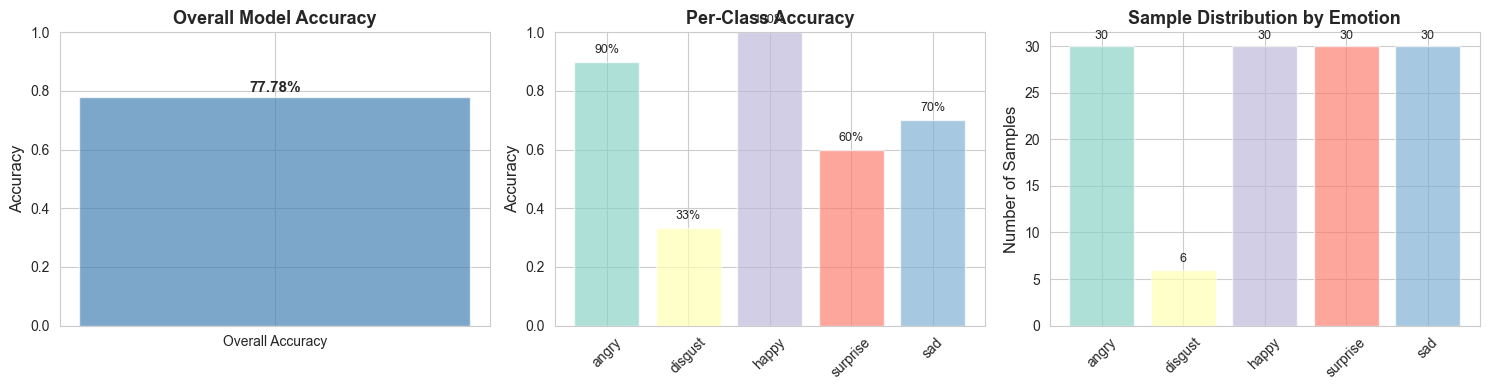


✓ Overall Accuracy: 77.78%
✓ angry: 90.00% (30 samples)
✓ disgust: 33.33% (6 samples)
✓ happy: 100.00% (30 samples)
✓ surprise: 60.00% (30 samples)
✓ sad: 70.00% (30 samples)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# 1. Overall Accuracy
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Overall Accuracy Bar Chart
overall_acc = accuracy_score(sampled_df['emotion'], sampled_df['predicted_emotion'])
axes[0].bar(['Overall Accuracy'], [overall_acc], color='steelblue', alpha=0.7)
axes[0].set_ylim([0, 1])
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Overall Model Accuracy', fontsize=13, fontweight='bold')
axes[0].text(0, overall_acc + 0.02, f'{overall_acc:.2%}', ha='center', fontsize=11, fontweight='bold')

# Plot 2: Per-Class Accuracy
emotion_accuracies = []
emotion_labels = []
for emotion in valid_emotions:
    subset = sampled_df[sampled_df['emotion'] == emotion]
    if len(subset) > 0:
        acc = accuracy_score(subset['emotion'], subset['predicted_emotion'])
        emotion_accuracies.append(acc)
        emotion_labels.append(emotion)

colors = plt.cm.Set3(range(len(emotion_labels)))
bars = axes[1].bar(emotion_labels, emotion_accuracies, color=colors, alpha=0.7)
axes[1].set_ylim([0, 1])
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for bar, acc in zip(bars, emotion_accuracies):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{acc:.0%}', ha='center', va='bottom', fontsize=9)

# Plot 3: Sample Distribution
sample_counts = sampled_df['emotion'].value_counts().reindex(emotion_labels, fill_value=0)
axes[2].bar(emotion_labels, sample_counts, color=colors, alpha=0.7)
axes[2].set_ylabel('Number of Samples', fontsize=12)
axes[2].set_title('Sample Distribution by Emotion', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(zip(emotion_labels, sample_counts)):
    axes[2].text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n✓ Overall Accuracy: {overall_acc:.2%}")
for emotion, acc in zip(emotion_labels, emotion_accuracies):
    subset = sampled_df[sampled_df['emotion'] == emotion]
    print(f"✓ {emotion}: {acc:.2%} ({len(subset)} samples)")

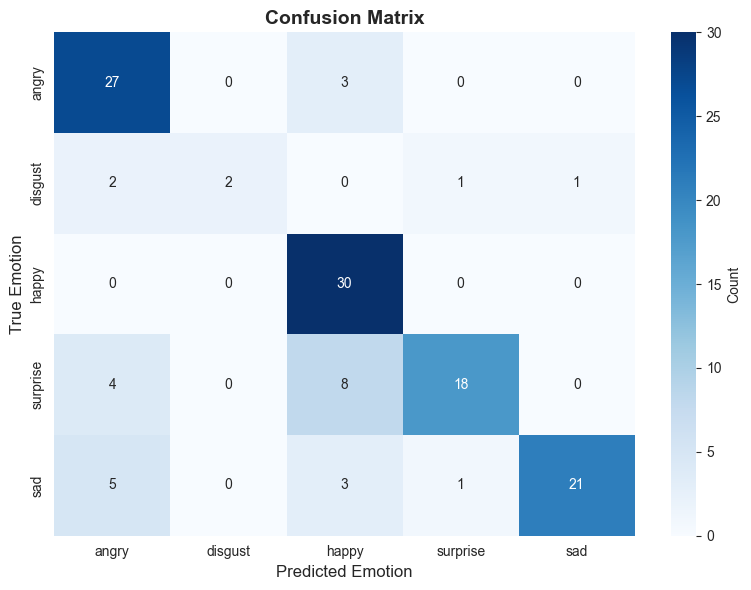

In [14]:
# Confusion Matrix Visualization
cm = confusion_matrix(sampled_df['emotion'], sampled_df['predicted_emotion'], labels=valid_emotions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=valid_emotions, 
            yticklabels=valid_emotions, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.tight_layout()
plt.show()

---

## Step 9: Analyze API Costs

Estimate costs based on token usage and extrapolate to full dataset:

In [15]:
# Cost estimation
# gpt-5-nano pricing (as of 2026): $0.05 per 1M input tokens, $0.40 per 1M output tokens
input_cost_per_million = 0.05
output_cost_per_million = 0.40

input_cost = (total_input_tokens / 1_000_000) * input_cost_per_million
output_cost = (total_output_tokens / 1_000_000) * output_cost_per_million
total_cost_sample = input_cost + output_cost

print(f"Cost for {len(sampled_df)} samples: ${total_cost_sample:.4f}")

# Extrapolate to full dataset
full_dataset_size = len(df_filtered)
scale_factor = full_dataset_size / len(sampled_df)
estimated_input_tokens = total_input_tokens * scale_factor
estimated_output_tokens = total_output_tokens * scale_factor
estimated_cost = (estimated_input_tokens / 1_000_000) * input_cost_per_million + (estimated_output_tokens / 1_000_000) * output_cost_per_million

print(f"Estimated cost for full dataset ({full_dataset_size} tweets): ${estimated_cost:.2f}")
print(f"Estimated tokens: Input {estimated_input_tokens:.0f}, Output {estimated_output_tokens:.0f}")

Cost for 126 samples: $0.0124
Estimated cost for full dataset (1267 tweets): $0.12
Estimated tokens: Input 268735, Output 276960


## Conclusion & Key Takeaways

You've successfully built an end-to-end emotion classification system using OpenAI's GPT-5-nano model with multi-dimensional emotion scoring.

### What We Accomplished
- ✅ Loaded and explored the SMILE Twitter dataset
- ✅ Designed structured prompts for JSON-based classification
- ✅ Built an API integration with error handling
- ✅ Evaluated model performance with per-class metrics
- ✅ Analyzed costs for scaling decisions

### Key Insights
- **Prompt Engineering Matters**: Structured JSON outputs improve reliability
- **Cost Scales Linearly**: Monitor token usage for budget planning
- **Multi-Score Classification**: Intensity scores provide more nuanced predictions than binary labels

### Next Steps for Production
- 🔧 Implement retry logic and rate limiting
- 💾 Add caching to reduce redundant API calls
- 📊 Fine-tune with domain-specific examples
- 🔐 Secure API keys with environment variables
- 📈 Set up monitoring for cost and performance